# Treasuries

This notebook uses `treasury_quotes_2020-09-30.xlsx`.

The workbook is read from the `quotes` sheet. Debt amounts are converted from dollars to **billions of dollars** to make the tables and charts easier to read.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

def locate_file(filename):
    candidates = [
        Path(filename),
        Path("data") / filename,
        Path("/mnt/data") / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"Could not find {filename}. Put it in the notebook folder "
        "or inside a data/ folder."
    )

file_path = locate_file("treasury_quotes_2020-09-30.xlsx")

quotes = pd.read_excel(file_path, sheet_name="quotes")
quotes["quote date"] = pd.to_datetime(quotes["quote date"])
quotes["maturity date"] = pd.to_datetime(quotes["maturity date"])

quotes["total size ($bn)"] = quotes["total size"] / 1e9

quotes["security group"] = quotes["type"].replace(
    {
        "bill": "Bills",
        "note": "Notes",
        "bond": "Bonds",
        "TIPS note": "TIPS",
        "TIPS bond": "TIPS",
    }
)

quotes.head()

,KYTREASNO,type,quote date,issue date,maturity date,ttm,accrual fraction,cpn rate,bid,ask,price,accrued int,dirty price,ytm,total size,public size,duration,total size ($bn),security group
0,207503,bill,2020-09-30,2020-04-02,2020-10-01,0.002738,0.994524,0.000,99.999853,99.999881,99.999867,0.000000,99.999867,0.000487,1.747520e+11,NaN,0.002740,174.752,Bills
1,207521,bill,2020-09-30,2020-05-05,2020-10-06,0.016427,0.967146,0.000,99.999000,99.999167,99.999083,0.000000,99.999083,0.000558,1.363870e+11,NaN,0.016438,136.387,Bills
2,207427,bill,2020-09-30,2019-10-10,2020-10-08,0.021903,0.956194,0.000,99.998778,99.999000,99.998889,0.000000,99.998889,0.000507,2.066680e+11,NaN,0.021918,206.668,Bills
3,207535,bill,2020-09-30,2020-05-12,2020-10-13,0.035592,0.928816,0.000,99.997653,99.998014,99.997833,0.000000,99.997833,0.000609,1.352900e+11,NaN,0.035616,135.290,Bills
4,207146,note,2020-09-30,2017-10-15,2020-10-15,0.041068,0.918033,1.625,100.039062,100.078125,100.058594,0.745902,100.804495,0.001934,2.399600e+10,2.091800e+10,0.041096,23.996,Notes


## 1.1 Total outstanding debt maturing at each date

The `total size` amounts are summed for all securities sharing the same maturity date.

In [2]:
debt_by_maturity = (
    quotes.pivot_table(
        index="maturity date",
        values="total size ($bn)",
        aggfunc="sum",
    )
    .sort_index()
)

debt_by_maturity.head()

,total size ($bn)
maturity date,
2020-10-01,174.752
2020-10-06,136.387
2020-10-08,206.668
2020-10-13,135.290
2020-10-15,207.492


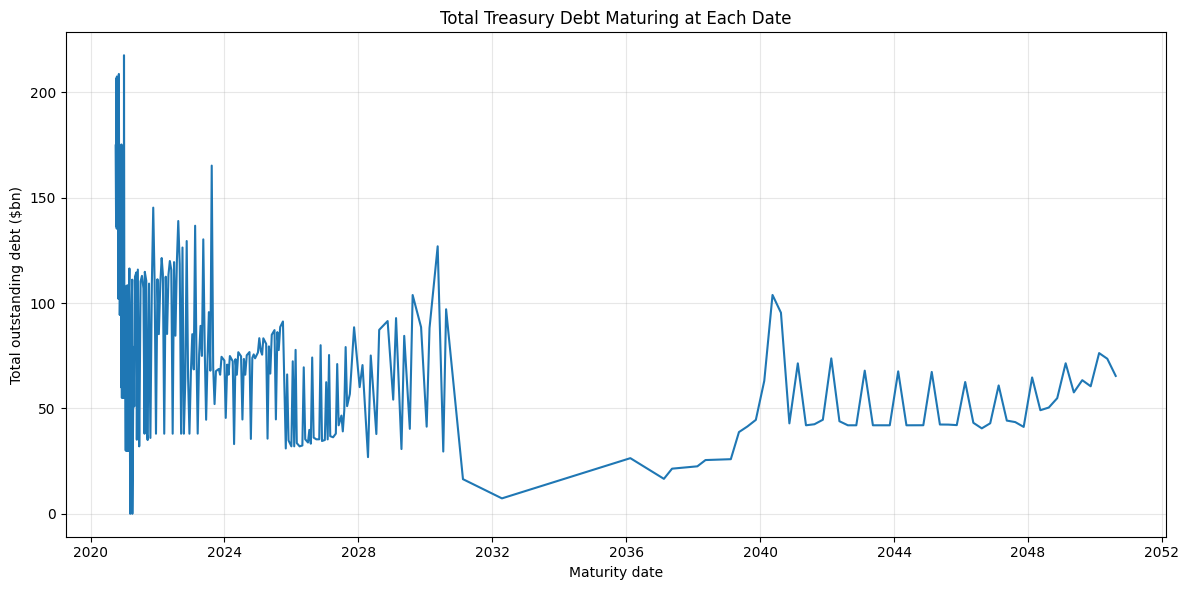

In [3]:
plt.figure(figsize=(12, 6))
plt.plot(
    debt_by_maturity.index,
    debt_by_maturity["total size ($bn)"],
)
plt.xlabel("Maturity date")
plt.ylabel("Total outstanding debt ($bn)")
plt.title("Total Treasury Debt Maturing at Each Date")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The graph shows that Treasury maturities are not distributed evenly through time. Large spikes correspond to dates on which especially large amounts of Treasury debt come due.

## 1.2 Outstanding debt by maturity and security type

TIPS notes and TIPS bonds are combined into one **TIPS** category. Bills are also shown so that the segmented chart reconciles to the total debt in Question 1.1.

In [4]:
debt_by_type = (
    quotes.pivot_table(
        index="maturity date",
        columns="security group",
        values="total size ($bn)",
        aggfunc="sum",
        fill_value=0,
    )
    .sort_index()
)

desired_order = ["Bills", "Notes", "Bonds", "TIPS"]
debt_by_type = debt_by_type[
    [column for column in desired_order if column in debt_by_type.columns]
]

debt_by_type.head()

security group,Bills,Notes,Bonds,TIPS
maturity date,,,,
2020-10-01,174.752,0.000,0.0,0.0
2020-10-06,136.387,0.000,0.0,0.0
2020-10-08,206.668,0.000,0.0,0.0
2020-10-13,135.290,0.000,0.0,0.0
2020-10-15,183.496,23.996,0.0,0.0


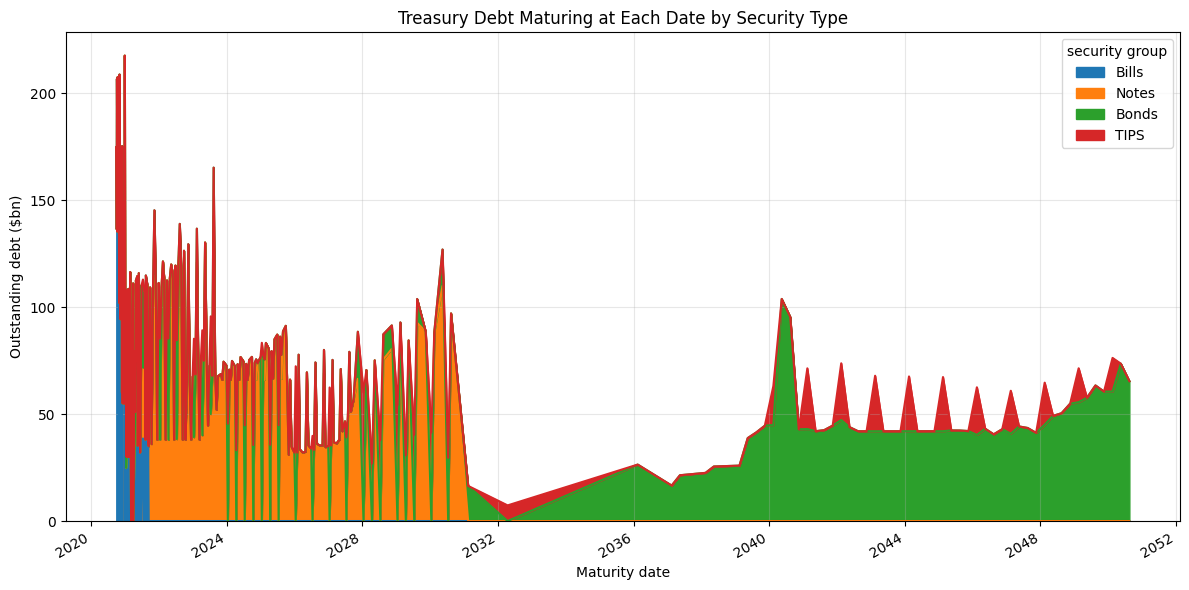

In [5]:
debt_by_type.plot(
    kind="area",
    stacked=True,
    figsize=(12, 6),
)
plt.xlabel("Maturity date")
plt.ylabel("Outstanding debt ($bn)")
plt.title("Treasury Debt Maturing at Each Date by Security Type")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Short-dated maturities are dominated by Treasury bills and notes. Bonds and TIPS generally have longer maturities and therefore appear farther out along the maturity schedule.

## 1.3 Total outstanding debt by security type

In [6]:
totals_by_type = (
    quotes.groupby("security group")["total size ($bn)"]
    .sum()
    .reindex(desired_order)
    .dropna()
    .sort_values(ascending=False)
)

shares_by_type = totals_by_type / totals_by_type.sum()

summary = pd.DataFrame(
    {
        "Total outstanding ($bn)": totals_by_type,
        "Share of total": shares_by_type,
    }
)

summary.style.format(
    {
        "Total outstanding ($bn)": "{:,.2f}",
        "Share of total": "{:.2%}",
    }
)

,Total outstanding ($bn),Share of total
security group,,
Notes,"10,663.73",53.62%
Bills,"5,028.90",25.28%
Bonds,"2,673.47",13.44%
TIPS,"1,523.19",7.66%


The table reports the total outstanding principal in each category and each category's share of the total represented in the dataset.

## 1.4 Pie chart of total outstanding debt

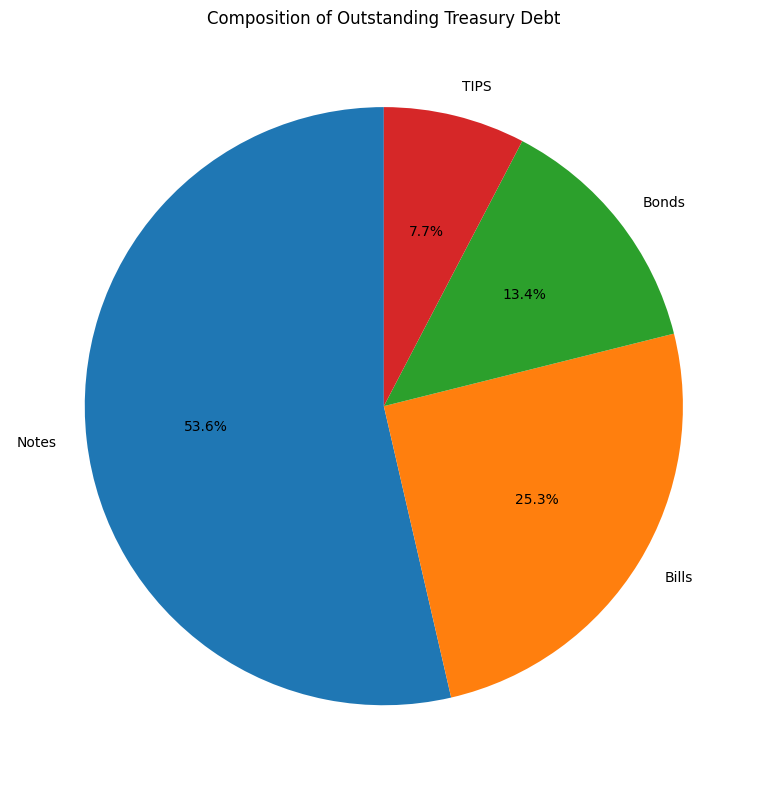

In [7]:
plt.figure(figsize=(8, 8))
plt.pie(
    totals_by_type,
    labels=totals_by_type.index,
    autopct="%1.1f%%",
    startangle=90,
)
plt.title("Composition of Outstanding Treasury Debt")
plt.tight_layout()
plt.show()

## 1.5 Time to maturity

Time to maturity is calculated relative to the quote date:

$$
\text{TTM}
=
\frac{\text{maturity date}-\text{quote date}}{365.25}.
$$

In [8]:
quotes["calculated ttm"] = (
    quotes["maturity date"] - quotes["quote date"]
).dt.days / 365.25

quotes["calculated ttm"].describe()

count    415.000000
mean       6.141092
std        7.987937
min        0.002738
25%        0.895277
50%        2.915811
75%        6.599589
max       29.872690
Name: calculated ttm, dtype: float64

In [9]:
quotes["ttm difference"] = quotes["calculated ttm"] - quotes["ttm"]

print(
    "Largest absolute difference versus the provided TTM:",
    quotes["ttm difference"].abs().max(),
)

Largest absolute difference versus the provided TTM: 3.552713678800501e-15


The summary statistics show the distribution of remaining maturities across all Treasury issues in the dataset. The small difference from the provided `ttm` field comes from day-count conventions and the use of 365.25 days per year.